Loading weights:   0%|          | 0/445 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: nlpconnect/vit-gpt2-image-captioning
Key                                                       | Status     |  | 
----------------------------------------------------------+------------+--+-
decoder.transformer.h.{0...11}.crossattention.masked_bias | UNEXPECTED |  | 
decoder.transformer.h.{0...11}.attn.masked_bias           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Saving Screenshot 2026-10-05 225335.png to Screenshot 2026-10-05 225335.png


[transformers] We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
You may ignore this warning if your `pad_token_id` (50256) is identical to the `bos_token_id` (50256), `eos_token_id` (50256), or the `sep_token_id` (None), and your input is not padded.


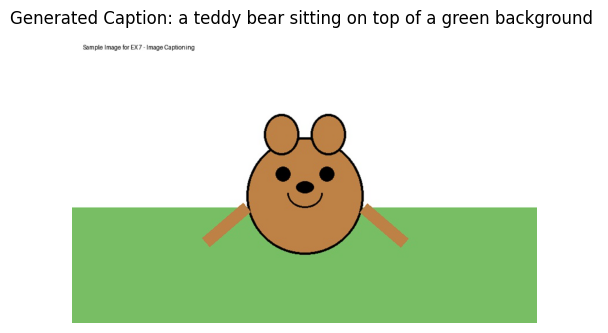

Generated Caption: a teddy bear sitting on top of a green background 
Image captioning completed successfully.


In [2]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_name = "nlpconnect/vit-gpt2-image-captioning"

model = VisionEncoderDecoderModel.from_pretrained(model_name).to(device)
processor = ViTImageProcessor.from_pretrained(model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)
model.eval()

uploaded = files.upload()
img_path = next(iter(uploaded))

image = Image.open(img_path).convert("RGB")
pixel_values = processor(images=image, return_tensors="pt").pixel_values.to(device)

with torch.no_grad():
    output_ids = model.generate(
        pixel_values,
        max_length=30,
        num_beams=2,
        early_stopping=True
    )

caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

plt.figure(figsize=(6, 5))
plt.imshow(image)
plt.axis("off")
plt.title("Generated Caption: " + caption)
plt.show()

print("Generated Caption:", caption)
print("Image captioning completed successfully.")